In [1]:
import numpy as np

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
print(f"Target names: {iris.target_names}")
iris.target.head(3)

Target names: ['setosa' 'versicolor' 'virginica']


0    0
1    0
2    0
Name: target, dtype: int64

In [4]:
X = iris.data.values
y = iris.target.values

In [5]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

In [6]:
class BatchGD():
    def __init__(self, learning_rate=0.1, n_epochs=100, patience=5):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.patience = patience

    def softmax(self, logits):
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)
    
    def cross_entropy(self, y_true, proba):
        return -np.mean(np.sum(y_true * np.log(proba + 1e-9), axis=1))

    def fit(self, X, y, X_val, y_val):
        m = len(X)
        n_features = X.shape[1]
        n_classes = y.shape[1]

        rng = np.random.default_rng(seed=42)
        self.theta = rng.standard_normal((n_features, n_classes))

        best_loss = np.inf
        best_theta = self.theta.copy()
        epochs_failed = 0

        for epoch in range(self.n_epochs):
            proba = self.softmax(X @ self.theta)
            gradients = 1 / m * X.T @ (proba - y)
            self.theta -= self.learning_rate * gradients

            training_loss = self.cross_entropy(y, proba)
            val_loss = self.cross_entropy(y_val, self.softmax(X_val @ self.theta))

            if(val_loss < best_loss):
                best_loss = val_loss
                best_theta = self.theta.copy()
                epochs_failed = 0
            else:
                epochs_failed += 1

            if(epochs_failed >= self.patience):
                print(f"stopped at epoch {epoch}")
                self.theta = best_theta
                return self.theta
        return self.theta
    
    def predict(self, X):
        return np.argmax(self.softmax(X @ self.theta), axis=1) 

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, add_dummy_feature

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False)

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_final = add_dummy_feature(X_train_scaled)
X_val_final   = add_dummy_feature(X_val_scaled)
X_test_final  = add_dummy_feature(X_test_scaled)

y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_val_encoded   = encoder.transform(y_val.reshape(-1, 1))

model = BatchGD(learning_rate=0.8, n_epochs=1000, patience=10)

In [8]:
model.fit(X_train_final, y_train_encoded, X_val_final, y_val_encoded)

stopped at epoch 461


array([[-0.10893612,  3.49321838, -3.36909809],
       [-1.49078094, -0.09928021, -0.72258883],
       [ 1.92253845, -0.14819662, -1.97954517],
       [-3.55537446, -0.46422479,  4.82374523],
       [-2.36159243, -0.51898504,  4.54135871]])

In [9]:
from sklearn.metrics import classification_report

pred_train = model.predict(X_train_final)
print(classification_report(y_train, pred_train))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      0.96      0.98        28
           2       0.97      1.00      0.98        31

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



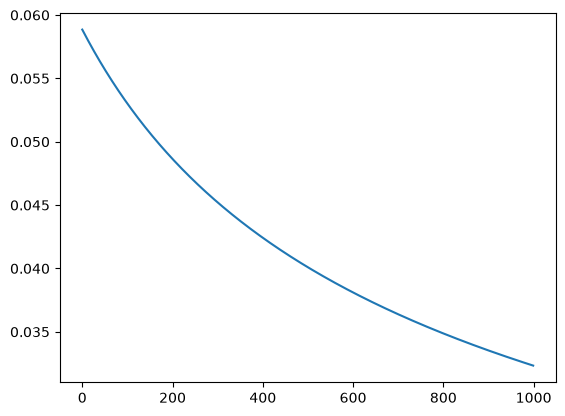

In [10]:
losses = []
m = len(X_train_final)
for epoch in range(model.n_epochs):
    proba = model.softmax(X_train_final @ model.theta)
    loss = -np.mean(np.sum(y_train_encoded * np.log(proba + 1e-9), axis=1))
    losses.append(loss)
    gradients = 1/m * X_train_final.T @ (proba - y_train_encoded)
    model.theta -= model.learning_rate * gradients

import matplotlib.pyplot as plt
plt.plot(losses)

In [11]:
from sklearn.metrics import classification_report

pred_test = model.predict(X_test_final)
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

